# Lib

In [ ]:
from pathlib import Path
import random
import glob
import os
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt

from face_recognition import *

import warnings
warnings.filterwarnings("ignore")

# Data

In [3]:
TRAIN_DIR = "../../dataset_face_recognition/train"
TEST_DIR = "../../dataset_face_recognition/test"
RAW_DIR = "../../dataset_face_recognition/raw"
TRAIN_DIR = Path(TRAIN_DIR)
TEST_DIR = Path(TEST_DIR)
RAW_DIR = Path(RAW_DIR)

In [4]:
OUTPUT_PREPROCESSING_DIR = "../../dataset_face_recognition/processed/"

In [5]:
print(f"Train dir: {TRAIN_DIR}")
print(f"Test dir: {TEST_DIR}")
print(f"Raw dir: {RAW_DIR}")

Train dir: ..\..\dataset_face_recognition\train
Test dir: ..\..\dataset_face_recognition\test
Raw dir: ..\..\dataset_face_recognition\raw


# Func

In [6]:
def list_class_dirs(root_dir):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        return []

    return sorted([d for d in root_dir.iterdir() if d.is_dir()])


def list_images(folder):
    folder = Path(folder)
    images = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
        images.extend(folder.glob(ext))
    return sorted(images)


def pick_sample_image(root_dir):
    root_dir = Path(root_dir)
    class_dirs = list_class_dirs(root_dir)

    if not class_dirs:
        return None, None

    class_dir = random.choice(class_dirs)
    image_paths = list_images(class_dir)

    if not image_paths:
        return class_dir.name, None

    return class_dir.name, random.choice(image_paths)


def show_image(image_path, title):
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Cannot read image: {image_path}")
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    return image_path

In [7]:
def visualize_preprocessing_steps(image_path, face_detector, target_size=(250, 250)):
    img = cv2.imread(image_path)
    if img is None:
        print("Cannot read image. Please check the path and try again.")
        return

    img_rgb = cv2.cvtColor(
        img, cv2.COLOR_BGR2RGB
    )
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bbox = face_detector.detect(gray_img)
    if bbox is None:
        print("Not found")
        return
    x1, y1, x2, y2 = bbox

    img_with_box = img_rgb.copy()
    cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (0, 255, 0), 3)

    face_crop = gray_img[y1:y2, x1:x2]

    face_resized = cv2.resize(face_crop, target_size)

    face_denoised = cv2.bilateralFilter(face_resized, d=9, sigmaColor=75, sigmaSpace=75)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    face_clahe = clahe.apply(face_denoised)

    mask = create_face_mask(target_size)
    face_final = (face_clahe.astype(np.float64) * mask).astype(np.uint8)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(
        f"Preprocessing", fontsize=16, fontweight="bold"
    )

    axes[0, 0].imshow(img_with_box)
    axes[0, 0].set_title("1. Face Detection (Bounding Box)")

    axes[0, 1].imshow(face_crop, cmap="gray")
    axes[0, 1].set_title("2. Crop")

    axes[0, 2].imshow(face_resized, cmap="gray")
    axes[0, 2].set_title(f"3. Resize ({target_size[0]}x{target_size[1]})")

    axes[1, 0].imshow(face_denoised, cmap="gray")
    axes[1, 0].set_title("4. Bilateral filter")

    axes[1, 1].imshow(face_clahe, cmap="gray")
    axes[1, 1].set_title("5. CLAHE")

    axes[1, 2].imshow(face_final, cmap="gray")
    axes[1, 2].set_title("6. Elliptical Mask")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
def test_preprocessing_on_image(image_path, face_detector=None):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"{image_path}")
    if face_detector is None:
        face_detector = HaarDetector()
    visualize_preprocessing_steps(image_path, face_detector)

# Check

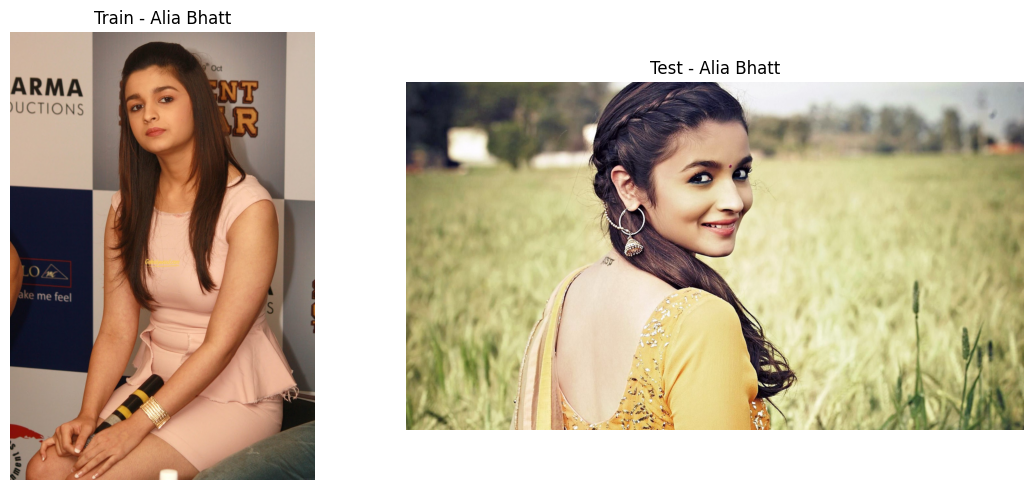

Class: Alia Bhatt
Train sample: Alia Bhatt_29.jpg
Test sample: Alia Bhatt_7.jpg


In [9]:
if TRAIN_DIR.exists() and TEST_DIR.exists():
    train_classes = list_class_dirs(TRAIN_DIR)
    test_classes = list_class_dirs(TEST_DIR)

    shared_classes = sorted(
        set(d.name for d in train_classes) & set(d.name for d in test_classes)
    )

    if not shared_classes:
        print("No shared class found between train and test.")
    else:
        sample_class = random.choice(shared_classes)
        train_images = list_images(TRAIN_DIR / sample_class)
        test_images = list_images(TEST_DIR / sample_class)

        if not train_images or not test_images:
            print(f"Class found but missing images in train/test: {sample_class}")
        else:
            train_sample = random.choice(train_images)
            test_sample = random.choice(test_images)

            plt.figure(figsize=(12, 5))

            plt.subplot(1, 2, 1)
            show_image(train_sample, f"Train - {sample_class}")

            plt.subplot(1, 2, 2)
            show_image(test_sample, f"Test - {sample_class}")

            plt.tight_layout()
            plt.show()

            print(f"Class: {sample_class}")
            print(f"Train sample: {train_sample.name}")
            print(f"Test sample: {test_sample.name}")
else:
    sample_class, sample_image = pick_sample_image(RAW_DIR)

    if sample_class is None:
        print("No class folders found.")
    elif sample_image is None:
        print(f"Class found but no images inside: {sample_class}")
    else:
        plt.figure(figsize=(6, 6))
        show_image(sample_image, f"Class: {sample_class}")
        plt.tight_layout()
        plt.show()
        print(f"Sample image: {sample_image.name}")

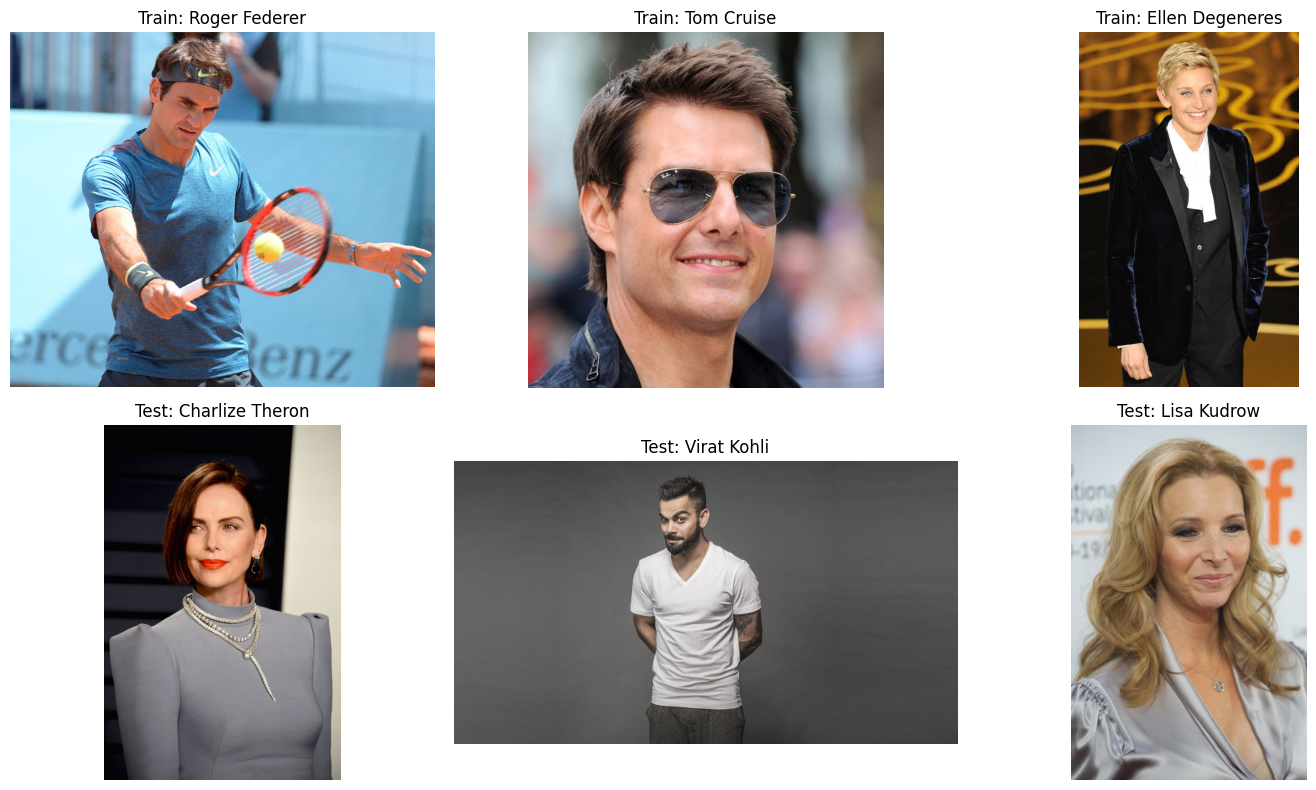

In [10]:
n_images = 3

plt.figure(figsize=(15, 8))

train_path = Path(TRAIN_DIR)
train_classes = list_class_dirs(train_path)
valid_train = [c for c in train_classes if list_images(c)]

if valid_train:
    sampled_train = random.sample(valid_train, min(n_images, len(valid_train)))
    for i, class_path in enumerate(sampled_train):
        img_path = random.choice(list_images(class_path))
        plt.subplot(2, n_images, i + 1)
        show_image(img_path, f"Train: {class_path.name}")
else:
    print("Not found any valid class or image in Train set.")


test_path = Path(TEST_DIR)
test_classes = list_class_dirs(test_path)
valid_test = [c for c in test_classes if list_images(c)]

if valid_test:
    sampled_test = random.sample(valid_test, min(n_images, len(valid_test)))
    for i, class_path in enumerate(sampled_test):
        img_path = random.choice(list_images(class_path))
        plt.subplot(2, n_images, n_images + i + 1)
        show_image(img_path, f"Test: {class_path.name}")
else:
    print("Not found any valid class or image in Test set.")

plt.tight_layout()
plt.show()

# Sample preprocessing

In [11]:
detector = HaarDetector()

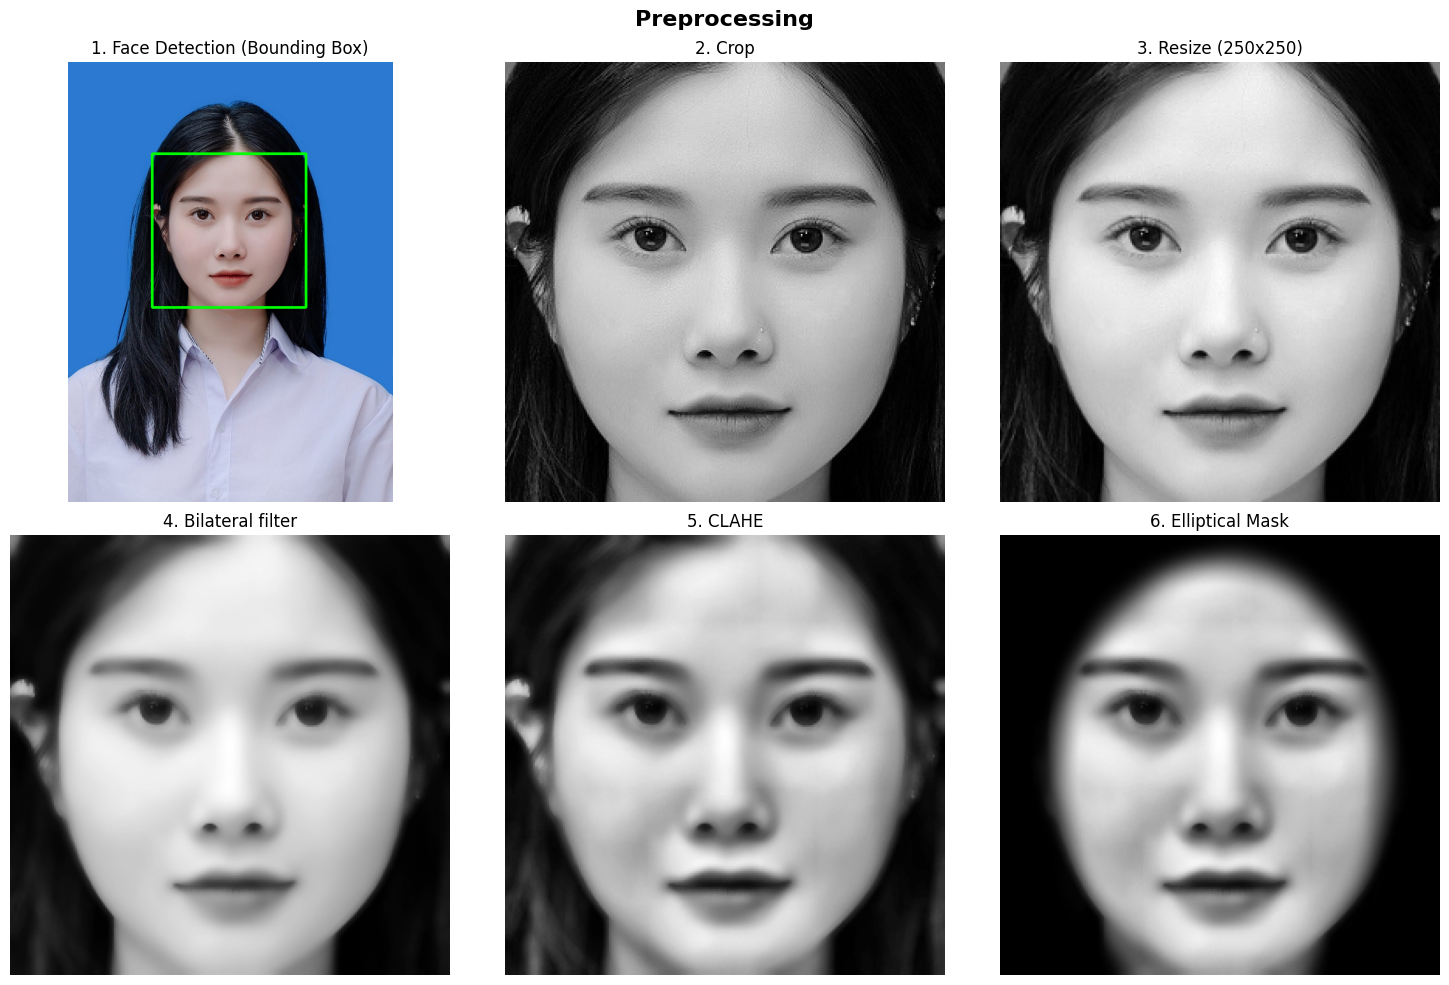

In [ ]:
test_preprocessing_on_image(r"..\..\dataset\test+gi.jpeg", detector)

Sample image: ..\..\dataset_face_recognition\train\Andy Samberg\Andy Samberg_89.jpg


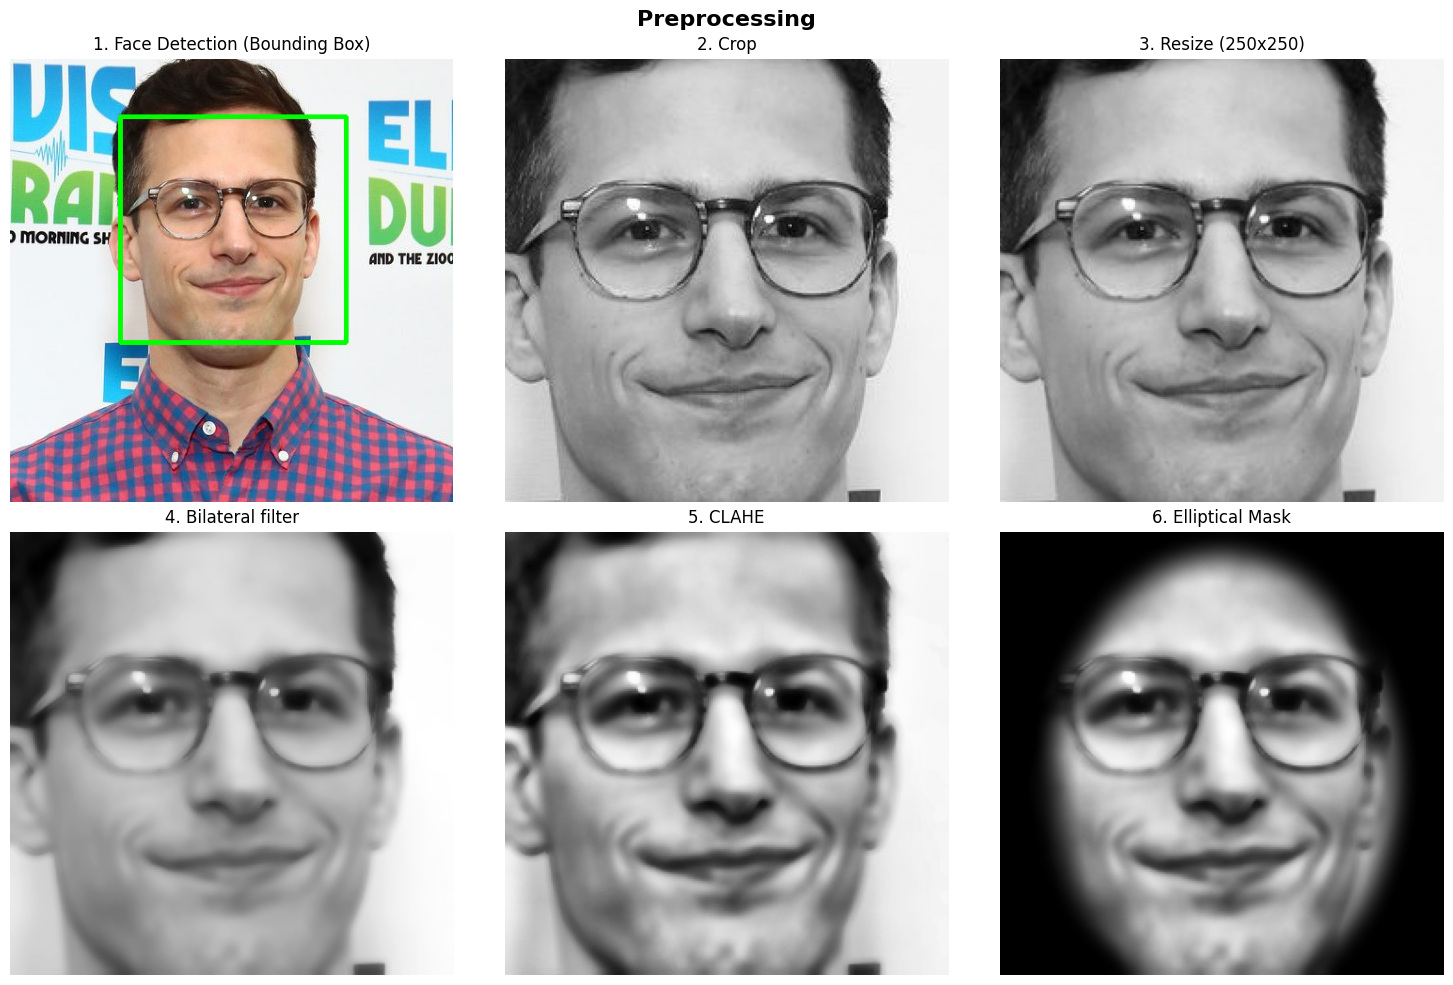

In [13]:
all_images = glob.glob(os.path.join(TRAIN_DIR, "*", "*.jpg"))

if len(all_images) > 0:
    sample_image_path = random.choice(all_images)
    print(f"Sample image: {sample_image_path}")

    visualize_preprocessing_steps(sample_image_path, detector)
else:
    raise FileNotFoundError("No images found in the training directory.")

# Preprocessing

In [14]:
if not os.path.exists(OUTPUT_PREPROCESSING_DIR):
    os.makedirs(OUTPUT_PREPROCESSING_DIR)

TRAIN_PREPROCESS_DIR = os.path.join(OUTPUT_PREPROCESSING_DIR, "train")
TEST_PREPROCESS_DIR = os.path.join(OUTPUT_PREPROCESSING_DIR, "test")

In [15]:
detector = HaarDetector()

target_size = (250, 250)

classes = [
    d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))
]

total_images = 0
success_count = 0
fail_count = 0

for person_name in classes:
    person_in_dir = os.path.join(TRAIN_DIR, person_name)
    person_out_dir = os.path.join(TRAIN_PREPROCESS_DIR, person_name)
    os.makedirs(person_out_dir, exist_ok=True)

    images = glob.glob(os.path.join(person_in_dir, "*.*"))

    for img_path in tqdm(images, desc=f"Processing {person_name}"):
        total_images += 1

        img = cv2.imread(img_path)
        if img is None:
            continue

        processed_img = preprocess_face(img, detector, target_size=target_size)

        if processed_img is not None:
            filename = os.path.basename(img_path)
            save_path = os.path.join(person_out_dir, filename)
            cv2.imwrite(save_path, processed_img)
            success_count += 1
        else:
            fail_count += 1

Processing Zac Efron: 100%|██████████| 88/88 [00:05<00:00, 15.57it/s]


In [16]:
detector = HaarDetector()

target_size = (250, 250)

classes = [d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))]

total_images = 0
success_count = 0
fail_count = 0

for person_name in classes:
    person_in_dir = os.path.join(TEST_DIR, person_name)
    person_out_dir = os.path.join(TEST_PREPROCESS_DIR, person_name)
    os.makedirs(person_out_dir, exist_ok=True)

    images = glob.glob(os.path.join(person_in_dir, "*.*"))

    for img_path in tqdm(images, desc=f"Processing {person_name}"):
        total_images += 1

        img = cv2.imread(img_path)
        if img is None:
            continue

        processed_img = preprocess_face(img, detector, target_size=target_size)

        if processed_img is not None:
            filename = os.path.basename(img_path)
            save_path = os.path.join(person_out_dir, filename)
            cv2.imwrite(save_path, processed_img)
            success_count += 1
        else:
            fail_count += 1

Processing Zac Efron: 100%|██████████| 34/34 [00:02<00:00, 14.58it/s]
